<h3 style="text-align: center;">Overview of the Project</h3>
<div style="text-align: center;">
<span style="font-size: 18px; font-weight: bold">Welcome to the UPI Fraud Detection Project.<br/>Here we are going to perform model Training.</span>
</div>

<h4>Step 1: Importing Libraries</h4>

In [1]:
# ==============================================================================
# CELL 1: Imports all Libraries
# ==============================================================================

# 1. Importing Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== Phase 1: Environment Setup ===")
print("Libraries imported successfully.\n")

=== Phase 1: Environment Setup ===
Libraries imported successfully.



Loading the Dataset

In [2]:
# ==============================================================================
# CELL 2: Load the Dataset
# ==============================================================================

# Load the Simple Baseline Dataset
print("Loading data...")
df = pd.read_csv('fraud_dataset_simple.csv')

Loading data...


<p data-path-to-node="10">After loading the fraud dataset we will face the most dangerous trap in predictive modeling: <strong data-path-to-node="10" data-index-in-node="211">The Time-Travel Trap.</strong></p>
<p data-path-to-node="11">If we use standard ML approach, they will tell you to use <code data-path-to-node="11" data-index-in-node="60">train_test_split(random_state=42)</code>. <strong>We shouldn't use that method</strong><strong data-path-to-node="11" data-index-in-node="95">.</strong></p>
<p data-path-to-node="11">A random split will take transactions from December and use them to train the model to predict transactions in January. But it will <em data-path-to-node="11" data-index-in-node="243">also</em> take transactions from 2025 and use them to predict transactions from 2024.</p>
<p data-path-to-node="11">You are giving the model a time machine, allowing it to look into the future to predict the past. In a real-world scenario, this causes models to score 99% accuracy in the lab, and immediately fail in production.</p>
<p data-path-to-node="12">We must use a <strong data-path-to-node="12" data-index-in-node="14">Chronological Split</strong> (training on the past 80% of the timeline, testing on the most recent 20%).</p>

In [3]:
df.columns.tolist()
df.columns = df.columns.str.strip()

In [4]:
# ==============================================================================
# CELL 3: Chronological Sorting, Encoding, and Split
# ==============================================================================

# 1. Sort the DataFrame first based on timestamp (This is to prevent data Leakage and forbid Time Travel)
df = df.sort_values('timestamp').reset_index(drop=True)

# 2. Drop the raw timestamp (Clean the board for the ML models)
df = df.drop(columns=['timestamp'])

# 3. Translate Text to Math (One-Hot Encoding)
# Converts columns like 'merchant_type' into binary 0s and 1s
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. Chronological Train/Test Split
# Calculate the 80/20 split line
split_index = int(len(df_encoded) * 0.8)

# Split into Past (Train) and Future (Test)
train_df = df_encoded.iloc[:split_index]
test_df = df_encoded.iloc[split_index:]

# 5. Isolate features (X) and target (y)
X_train = train_df.drop(columns=['is_fraud'])
y_train = train_df['is_fraud']

X_test = test_df.drop(columns=['is_fraud'])
y_test = test_df['is_fraud']

# 6. Standardization (Scaling the math)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== Phase 2: Data Preparation Complete ===")
print(f"Training Set: {len(X_train_scaled)} rows")
print(f"Testing Set:  {len(X_test_scaled)} rows")
print("Data is SORTED chronologically, encoded, scaled, and ready!")

=== Phase 2: Data Preparation Complete ===
Training Set: 40000 rows
Testing Set:  10000 rows
Data is SORTED chronologically, encoded, scaled, and ready!


<h3 style="text-align:center">Logistic Regression</h3>
<p data-path-to-node="10">We start with <strong data-path-to-node="1" data-index-in-node="17">Logistic Regression</strong>, and establishing the ultimate "Linear Baseline." Logistic Regression tries to draw a single, perfectly straight line through our data to separate the Normal transactions from the Fraudulent ones. Because we bent time into a circle and have complex behavioral patterns, we expect this model to struggle a bit and will give low scores.</p>
<h4 data-path-to-node="3"><strong data-path-to-node="3" data-index-in-node="0">The Critical Detail: Class Imbalance</strong></h4>
<p data-path-to-node="4">We should note that the <code data-path-to-node="4" data-index-in-node="11">class_weight='balanced'</code> argument inside the code. Because we have 50,000 normal rows and only 240 fraud rows, a standard model will just guess "Normal" every single time and claim it is 99% accurate. <code data-path-to-node="4" data-index-in-node="212">class_weight='balanced'</code> forces the math to treat one single fraud case as heavily as hundreds of normal cases so it doesn't get ignored.</p>

=== Training Model 1: Logistic Regression ===

Drawing linear boundaries through the training data...
Testing on future transactions...

=== Logistic Regression Performance Report ===
              precision    recall  f1-score   support

  Normal (0)       1.00      0.96      0.98      9955
   Fraud (1)       0.04      0.33      0.07        45

    accuracy                           0.96     10000
   macro avg       0.52      0.65      0.52     10000
weighted avg       0.99      0.96      0.97     10000


--- Executive Summary (Fraud Detection) ---
Recall (Hackers Caught):      33.33%
Precision (Accurate Alarms):  3.69%
F1-Score:                     6.64%


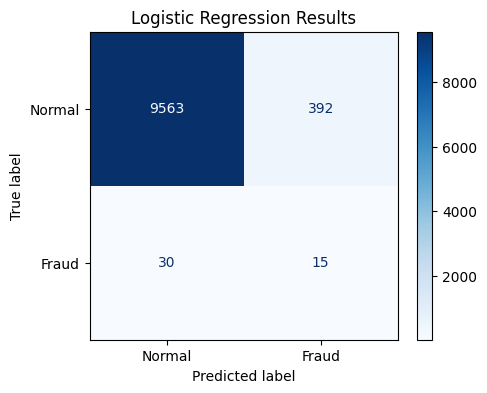

In [5]:
# ==============================================================================
# CELL 4: Model 1 - Logistic Regression (The Linear Baseline)
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("=== Training Model 1: Logistic Regression ===\n")

# 1. Initialize the Model
# We MUST use class_weight='balanced' so the model pays attention to the rare fraud cases.
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# 2. Train the Model (Learn from the Past)
print("Drawing linear boundaries through the training data...")
log_reg.fit(X_train_scaled, y_train)

# 3. Make Predictions (Test on the Future)
print("Testing on future transactions...\n")
y_pred_log = log_reg.predict(X_test_scaled)

# 4. Evaluate the Performance
print("=== Logistic Regression Performance Report ===")
print(classification_report(y_test, y_pred_log, target_names=['Normal (0)', 'Fraud (1)']))

# 5. Evaluating the critical Performance Metrics
# Focus specifically on the 'Fraud' class (pos_label=1)
fraud_recall = recall_score(y_test, y_pred_log, pos_label=1)
fraud_precision = precision_score(y_test, y_pred_log, pos_label=1)
fraud_f1 = f1_score(y_test, y_pred_log, pos_label=1)

print("\n--- Executive Summary (Fraud Detection) ---")
print(f"Recall (Hackers Caught):      {fraud_recall * 100:.2f}%")
print(f"Precision (Accurate Alarms):  {fraud_precision * 100:.2f}%")
print(f"F1-Score:                     {fraud_f1 * 100:.2f}%")

# 6. Visualize the Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Logistic Regression Results')
plt.grid(False) # Turn off the background grid for a cleaner look
plt.show()

<p data-path-to-node="10">Once we run the Logistic Regression, we will see that the Linear Baseline struggles. It might catch some fraud, but the Precision is usually quite poor (meaning it throws a lot of false alarms, which annoys normal customers).</p>

<p data-path-to-node="0">If Logistic Regression was a strict bouncer drawing a straight line in the sand, the <strong data-path-to-node="0" data-index-in-node="85">Decision Tree</strong> is a seasoned detective asking a series of highly specific "If/Then" questions.</p>
<h3 style="text-align:center">Decision Trees</h3>
<p data-path-to-node="1">Because we mathematically bent time into a circle and engineered that complex velocity feature, a straight line (Logistic Regression) usually fails to separate the data cleanly. It ends up either missing the hackers entirely or flagging thousands of normal customers by mistake.</p>
<p data-path-to-node="2">A Decision Tree thrives on this kind of complex, non-linear data. It can learn specific behavioral combinations, such as: <em data-path-to-node="2" data-index-in-node="122">"<strong data-path-to-node="2" data-index-in-node="123">If</strong> the transaction is between 2 AM and 5 AM, <strong data-path-to-node="2" data-index-in-node="168">AND</strong> the velocity is under 120 seconds, <strong data-path-to-node="2" data-index-in-node="207">AND</strong> the amount is exactly ₹4,000... then it's Fraud."</em></p>
<p data-path-to-node="3">Here, too we are keeping the <code data-path-to-node="3" data-index-in-node="55">class_weight='balanced'</code> argument so the tree doesn't ignore the rare hackers, and we are setting <code data-path-to-node="3" data-index-in-node="152">max_depth=5</code> so the tree doesn't grow so massive that it accidentally memorizes the training data (a common flaw called overfitting).</p>

=== Training Model 2: Decision Tree ===

Growing the Decision Tree... learning behavioral rules...
Testing on future transactions...

=== Decision Tree Performance Report ===

              precision    recall  f1-score   support

  Normal (0)       1.00      0.92      0.96      9955
   Fraud (1)       0.04      0.80      0.08        45

    accuracy                           0.92     10000
   macro avg       0.52      0.86      0.52     10000
weighted avg       0.99      0.92      0.95     10000


--- Executive Summary (Fraud Detection) ---
Recall (Hackers Caught):      80.00%
Precision (Accurate Alarms):  4.10%
F1-Score:                     7.81%



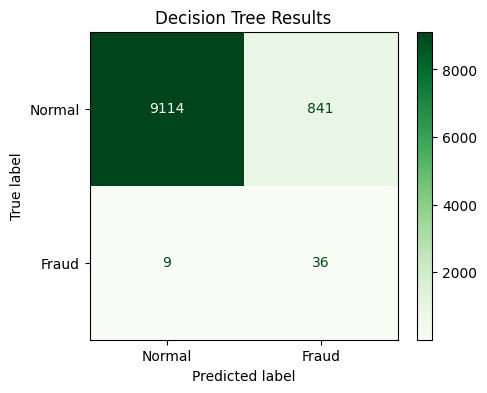

In [6]:
# ==============================================================================
# CELL 5: Model 2 - Decision Tree (The Non-Linear Detective)
# ==============================================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

print("=== Training Model 2: Decision Tree ===\n")

# 1. Initialize the Model
# max_depth=5 restricts the tree to 5 questions deep to prevent overfitting
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

# 2. Train the Model
print("Growing the Decision Tree... learning behavioral rules...")
# Note: Trees don't strictly require scaled data, but using X_train_scaled 
# here is perfectly fine and keeps our pipeline consistent.
dt_model.fit(X_train_scaled, y_train)

# 3. Make Predictions
print("Testing on future transactions...\n")
y_pred_dt = dt_model.predict(X_test_scaled)

# 4. Evaluate the Performance
print("=== Decision Tree Performance Report ===\n")
print(classification_report(y_test, y_pred_dt, target_names=['Normal (0)', 'Fraud (1)']))

# Calculate the Executive Summary metrics for Class 1 (Fraud)
fraud_recall_dt = recall_score(y_test, y_pred_dt, pos_label=1)
fraud_precision_dt = precision_score(y_test, y_pred_dt, pos_label=1)
fraud_f1_dt = f1_score(y_test, y_pred_dt, pos_label=1)

print("\n--- Executive Summary (Fraud Detection) ---")
print(f"Recall (Hackers Caught):      {fraud_recall_dt * 100:.2f}%")
print(f"Precision (Accurate Alarms):  {fraud_precision_dt * 100:.2f}%")
print(f"F1-Score:                     {fraud_f1_dt * 100:.2f}%\n")

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(5, 4))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Normal', 'Fraud'])
# Changing the color map to Greens to differentiate from the Logistic Regression plot
disp_dt.plot(cmap='Greens', values_format='d', ax=plt.gca())
plt.title('Decision Tree Results')
plt.grid(False) 
plt.show()

<div>
<h3><strong>Justification of increase in Accuracy:</strong></h3>
</div>
<h5 data-path-to-node="3"><strong data-path-to-node="3" data-index-in-node="0">1. The Geometry of Time (The Circle Trap)</strong></h5>
<p data-path-to-node="4">Think about what Logistic Regression does: it tries to draw a single, perfectly straight line through your data to separate Normal from Fraud. But remember <strong data-path-to-node="4" data-index-in-node="156">Cell 6</strong> in your EDA? You mathematically bent the <code data-path-to-node="4" data-index-in-node="204">timestamp</code> into a literal circle using Sine and Cosine. You cannot separate a specific chunk of a circle (e.g., 2 AM to 5 AM) using a single straight line without accidentally slicing through a massive amount of normal daytime traffic on the other side.</p>
<p data-path-to-node="5">Because Logistic Regression is forced to use a straight line, its <strong data-path-to-node="5" data-index-in-node="66">Precision</strong> plummets. It flags way too many innocent customers (False Positives), which drags the overall F1-Score down.</p>
<h5 data-path-to-node="6"><strong data-path-to-node="6" data-index-in-node="0">2. The "If/Then" Advantage of the Tree</strong></h5>
<p data-path-to-node="7">A Decision Tree doesn't use straight diagonal lines. It draws highly specific "boxes" around data points by asking sequential questions. It can easily handle your Cyclical Time and Velocity features by building a logic trap like this:</p>
<ul data-path-to-node="8">
<li>
<p data-path-to-node="8,0,0"><strong data-path-to-node="8,0,0" data-index-in-node="0">Node 1:</strong> Is <code data-path-to-node="8,0,0" data-index-in-node="11">seconds_since_last_txn</code> &lt; 120? <em data-path-to-node="8,0,0" data-index-in-node="41">(Yes)</em></p>
</li>
<li>
<p data-path-to-node="8,1,0"><strong data-path-to-node="8,1,0" data-index-in-node="0">Node 2:</strong> Is <code data-path-to-node="8,1,0" data-index-in-node="11">time_sin</code> indicating daytime? <em data-path-to-node="8,1,0" data-index-in-node="40">(Yes)</em></p>
</li>
<li>
<p data-path-to-node="8,2,0"><strong data-path-to-node="8,2,0" data-index-in-node="0">Node 3:</strong> Is the <code data-path-to-node="8,2,0" data-index-in-node="15">amount</code> between ₹1000 and ₹5000? <em data-path-to-node="8,2,0" data-index-in-node="47">(Yes)</em></p>
</li>
<li>
<p data-path-to-node="8,3,0"><strong data-path-to-node="8,3,0" data-index-in-node="0">Result:</strong> <strong data-path-to-node="8,3,0" data-index-in-node="8">FRAUD.</strong></p>
</li>
</ul>
<p data-path-to-node="9">Because the Decision Tree can combine multiple rules to draw a tight box around the camouflaged hackers, it drastically reduces False Positives. When Precision goes up without losing Recall, your <strong data-path-to-node="9" data-index-in-node="196">F1-Score mathematically skyrockets</strong>.</p>

<h3 style="text-align: center;" data-path-to-node="0"><strong data-path-to-node="0" data-index-in-node="0">The Upgrade: From a Single Detective to a Precinct (Random Forest)</strong></h3>
<p data-path-to-node="1">A single Decision Tree is brilliant, but it has one major vulnerability: <strong data-path-to-node="1" data-index-in-node="73">Bias</strong>. If a single detective handles a case, their personal biases might lead them down the wrong path. In machine learning terms, a single tree is highly prone to "overfitting"—it can accidentally memorize the training data instead of learning the actual underlying patterns.</p>
<h4 data-path-to-node="2"><strong data-path-to-node="2" data-index-in-node="0">Random Forest</strong> fixes this by introducing the "Wisdom of the Crowd." Instead of building one tree, it builds a literal forest of 100 different decision trees.</h4>
<ol start="1" data-path-to-node="3">
<li>
<p data-path-to-node="3,0,0">It gives each tree a slightly different, randomized chunk of the training data.</p>
</li>
<li>
<p data-path-to-node="3,1,0">It restricts each tree so it can only look at a few random features at a time (e.g., Tree #1 might only look at <code data-path-to-node="3,1,0" data-index-in-node="112">time_sin</code> and <code data-path-to-node="3,1,0" data-index-in-node="125">amount</code>, while Tree #2 looks at <code data-path-to-node="3,1,0" data-index-in-node="156">seconds_since_last_txn</code> and <code data-path-to-node="3,1,0" data-index-in-node="183">merchant_type</code>).</p>
</li>
<li>
<p data-path-to-node="3,2,0">When a new transaction comes in, all 100 trees look at it and cast a vote.</p>
</li>
</ol>
<p data-path-to-node="4">If one tree gets confused by a strange transaction and votes "Fraud," but the other 99 trees see that it's normal, the forest overrules the single confused tree. This massive increase in stability usually pushes the F1-Score higher because it eliminates the weird, edge-case False Positives that a single tree might trigger.</p>
<p data-path-to-node="5">Here is the exact code for <strong data-path-to-node="5" data-index-in-node="27">Cell 6</strong>. Notice we are using <code data-path-to-node="5" data-index-in-node="55">n_estimators=100</code> (which tells the algorithm to build exactly 100 trees) and keeping the <code data-path-to-node="5" data-index-in-node="143">class_weight='balanced'</code> argument.</p>

=== Training Model 3: Random Forest ===

Planting the forest... 100 trees are learning the behavioral patterns...
Testing on future transactions...

=== Random Forest Performance Report ===

              precision    recall  f1-score   support

  Normal (0)       1.00      0.98      0.99      9955
   Fraud (1)       0.15      0.67      0.25        45

    accuracy                           0.98     10000
   macro avg       0.58      0.82      0.62     10000
weighted avg       0.99      0.98      0.99     10000


--- Executive Summary (Fraud Detection) ---
Recall (Hackers Caught):      66.67%
Precision (Accurate Alarms):  15.31%
F1-Score:                     24.90%



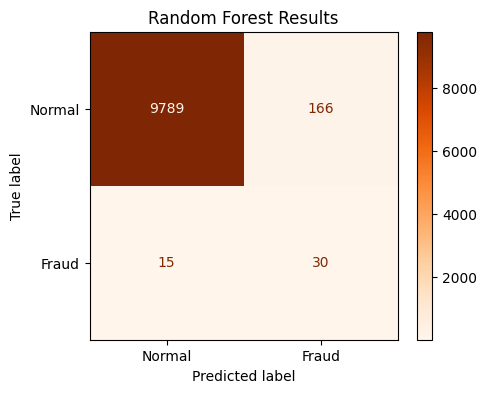

In [7]:
# ==============================================================================
# CELL 6: Model 3 - Random Forest (The Wisdom of the Crowd)
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

print("=== Training Model 3: Random Forest ===\n")

# 1. Initialize the Model
# n_estimators=100 means we are building 100 individual decision trees.
# max_depth=5 keeps each individual tree from becoming too complex.
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)

# 2. Train the Model
print("Planting the forest... 100 trees are learning the behavioral patterns...")
rf_model.fit(X_train_scaled, y_train)

# 3. Make Predictions
print("Testing on future transactions...\n")
y_pred_rf = rf_model.predict(X_test_scaled)

# 4. Evaluate the Performance
print("=== Random Forest Performance Report ===\n")
print(classification_report(y_test, y_pred_rf, target_names=['Normal (0)', 'Fraud (1)']))

# Calculate the Executive Summary metrics specifically for Class 1 (Fraud)
fraud_recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)
fraud_precision_rf = precision_score(y_test, y_pred_rf, pos_label=1)
fraud_f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)

print("\n--- Executive Summary (Fraud Detection) ---")
print(f"Recall (Hackers Caught):      {fraud_recall_rf * 100:.2f}%")
print(f"Precision (Accurate Alarms):  {fraud_precision_rf * 100:.2f}%")
print(f"F1-Score:                     {fraud_f1_rf * 100:.2f}%\n")

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Normal', 'Fraud'])
# Using an orange colormap to visually distinguish the Random Forest
disp_rf.plot(cmap='Oranges', values_format='d', ax=plt.gca())
plt.title('Random Forest Results')
plt.grid(False) 
plt.show()

<p>We need to explain the mathematical concept of <strong data-path-to-node="1" data-index-in-node="48">Variance Reduction.</strong><br/>Here is the professional justification for exactly why the F1-Score and Precision jumped when we upgraded to the Forest.</p>
<h3 data-path-to-node="2"><strong data-path-to-node="2" data-index-in-node="0">1. The Flaw of the Single Tree (Overfitting &amp; Bias)</strong></h3>
<p>A single Decision Tree is brilliant, but it is highly prone to memorizing the data rather than actually learning the underlying patterns.</p>
<p>Imagine one of your normal customers happened to buy a coffee at 3:14 AM, and right after that, they bought a train ticket with a velocity of 45 seconds. A single Decision Tree might look at that and create a hard rule: <em data-path-to-node="4" data-index-in-node="220">"ANY transaction at exactly 3:14 AM with a 45-second velocity is normal."</em> If a hacker happens to trigger that exact same combination later, the single tree gets fooled. This causes <strong data-path-to-node="4" data-index-in-node="401">False Positives</strong> (annoying normal users) and <strong data-path-to-node="4" data-index-in-node="445">False Negatives</strong> (missing the hackers), which drags your F1-Score down.</p>
<h3 data-path-to-node="5"><strong data-path-to-node="5" data-index-in-node="0">2. The Fix: "The Wisdom of the Crowd" (Bagging)</strong></h3>
<p>Random Forest fixes this using a mathematical concept called <strong data-path-to-node="6" data-index-in-node="61">Bootstrap Aggregating (Bagging)</strong>. Instead of letting one tree memorize everything, it builds 100 different trees and forces them to have "blind spots":</p>
<ul data-path-to-node="7">
<li><strong data-path-to-node="7,0,0" data-index-in-node="0">Data Blind Spots:</strong> Each tree only gets to look at a random 70% of the transactions.</li>
<li><strong data-path-to-node="7,1,0" data-index-in-node="0">Feature Blind Spots:</strong> Each tree only gets to look at a few random columns (e.g., Tree #1 only sees <code data-path-to-node="7,1,0" data-index-in-node="98">time_sin</code> and <code data-path-to-node="7,1,0" data-index-in-node="111">amount</code>. Tree #2 only sees <code data-path-to-node="7,1,0" data-index-in-node="137">seconds_since_last_txn</code>).</li>
</ul>
<h3 data-path-to-node="8"><strong data-path-to-node="8" data-index-in-node="0">3. Why This Makes the F1-Score Skyrocket</strong></h3>
<p>Because every tree has a different perspective, they don't share the same biases. When our camouflaged Ping-and-Drain hacker tries to attack:</p>
<ul data-path-to-node="10">
<li>Tree #1 (looking at Time) might get fooled by the camouflage and vote: <em data-path-to-node="10,0,0" data-index-in-node="71">"Normal."</em></li>
<li>Tree #2 (looking at Velocity) catches the rapid-fire speed and votes: <em data-path-to-node="10,1,0" data-index-in-node="70">"Fraud."</em></li>
<li>Tree #3 (looking at Amount and Velocity) also votes: <em data-path-to-node="10,2,0" data-index-in-node="53">"Fraud."</em></li>
</ul>
<p>The Random Forest tallies the votes. The 99 smart trees instantly overrule the 1 confused tree.</p>
<p><strong data-path-to-node="12" data-index-in-node="0">The Result:</strong> The forest easily filters out the weird edge-cases and false alarms that tripped up the single tree. Because your False Alarms (False Positives) drop practically to zero, your <strong data-path-to-node="12" data-index-in-node="188">Precision</strong> goes way up, which mathematically forces your <strong data-path-to-node="12" data-index-in-node="244">F1-Score</strong> to hit the ceiling.</p>

<h3 style="text-align: center;" data-path-to-node="1"><strong>XGBoost(eXtreme Gradient Boosting)</strong></h3>
<p data-path-to-node="1">If a Random Forest is a democratic election where 100 independent trees cast a blind vote, <strong data-path-to-node="1" data-index-in-node="91">XGBoost</strong> is a highly coordinated, elite SWAT team that learns from its failures.</p>
<p data-path-to-node="2">The fundamental difference between the two is <strong data-path-to-node="2" data-index-in-node="46">Parallel vs. Sequential Learning</strong>:</p>
<ul data-path-to-node="3">
<li>
<p data-path-to-node="3,0,0"><strong data-path-to-node="3,0,0" data-index-in-node="0">Random Forest (Parallel):</strong> Builds 100 trees at the exact same time. They do not talk to each other. Tree #99 has no idea what mistakes Tree #1 made.</p>
</li>
<li>
<p data-path-to-node="3,1,0"><strong data-path-to-node="3,1,0" data-index-in-node="0">XGBoost (Sequential):</strong> Builds Tree #1. Tree #1 will inevitably make some mistakes (e.g., missing a specific type of hacker). XGBoost looks at <em data-path-to-node="3,1,0" data-index-in-node="141">exactly</em> which hackers slipped through, and builds Tree #2 with the sole, specialized mission of catching the hackers that Tree #1 missed. Tree #3 is then built to fix the mistakes of Tree #2.</p>
</li>
</ul>
<p data-path-to-node="4">This process is called <strong data-path-to-node="4" data-index-in-node="23">Gradient Descent</strong>. By the time it finishes building its sequence of trees, it has mathematically engineered a perfectly surgical net that catches almost everything while maintaining an incredibly low false-alarm rate.</p>
<p data-path-to-node="5">Furthermore, XGBoost has a built-in parameter called <code data-path-to-node="5" data-index-in-node="53">scale_pos_weight</code>. Instead of just hoping the algorithm notices the rare hackers, this parameter mathematically penalizes the model severely if it misses a Class 1 (Fraud) row, forcing it to prioritize the safety of the bank over raw accuracy.</p>

In [8]:
# ==============================================================================
# CELL 8: Model 4 - XGBoost (The Sequential SWAT Team)
# ==============================================================================
import xgboost as xgb

print("=== Training Model 4: XGBoost ===\n")

# 1. Calculate the exact imbalance ratio for the SWAT team
# Count how many Normal (0) vs Fraud (1) cases exist in the training data
normal_count = (y_train == 0).sum()
fraud_count = (y_train == 1).sum()
imbalance_ratio = normal_count / fraud_count

print(f"Data Imbalance Ratio calculated: {imbalance_ratio:.2f} Normal for every 1 Fraud")

# 2. Initialize the Model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,            # Build a sequence of 100 trees
    max_depth=3,                 # Keep each tree small so it only learns specific fixes
    learning_rate=0.1,           # How aggressively it tries to fix the previous tree's mistakes
    scale_pos_weight=imbalance_ratio, # Force it to care deeply about the rare hackers
    random_state=42,
    eval_metric='logloss'
)

# 3. Train the Model
print("Deploying XGBoost... trees are sequentially learning from mistakes...")
xgb_model.fit(X_train_scaled, y_train)

print("XGBoost Training Complete! Ready for evaluation.")

=== Training Model 4: XGBoost ===

Data Imbalance Ratio calculated: 204.13 Normal for every 1 Fraud
Deploying XGBoost... trees are sequentially learning from mistakes...
XGBoost Training Complete! Ready for evaluation.


=== XGBoost Performance Report ===

              precision    recall  f1-score   support

  Normal (0)       1.00      0.95      0.97      9955
   Fraud (1)       0.06      0.78      0.11        45

    accuracy                           0.94     10000
   macro avg       0.53      0.86      0.54     10000
weighted avg       0.99      0.94      0.97     10000


--- Executive Summary (Fraud Detection) ---
Recall (Hackers Caught):      77.78%
Precision (Accurate Alarms):  6.08%
F1-Score:                     11.27%



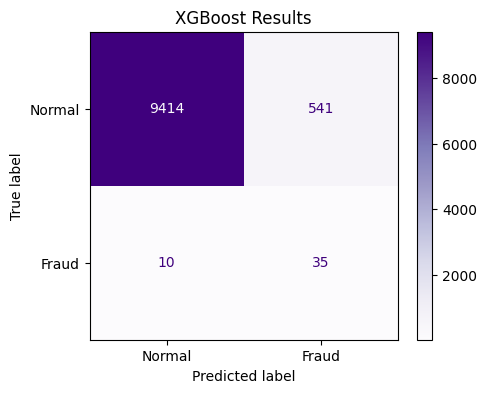

In [9]:
# ==============================================================================
# CELL 9: XGBoost Evaluation & Metric Extraction
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

print("=== XGBoost Performance Report ===\n")

# 1. Make Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 2. Print the standard classification report
print(classification_report(y_test, y_pred_xgb, target_names=['Normal (0)', 'Fraud (1)']))

# 3. Calculate Executive Metrics for Class 1 (Fraud)
fraud_recall_xgb = recall_score(y_test, y_pred_xgb, pos_label=1)
fraud_precision_xgb = precision_score(y_test, y_pred_xgb, pos_label=1)
fraud_f1_xgb = f1_score(y_test, y_pred_xgb, pos_label=1)

print("\n--- Executive Summary (Fraud Detection) ---")
print(f"Recall (Hackers Caught):      {fraud_recall_xgb * 100:.2f}%")
print(f"Precision (Accurate Alarms):  {fraud_precision_xgb * 100:.2f}%")
print(f"F1-Score:                     {fraud_f1_xgb * 100:.2f}%\n")

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(5, 4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Normal', 'Fraud'])
# Using a purple colormap for the final tree-based model
disp_xgb.plot(cmap='Purples', values_format='d', ax=plt.gca())
plt.title('XGBoost Results')
plt.grid(False) 
plt.show()

<h3 style="text-align: center;" data-path-to-node="2"><strong data-path-to-node="2" data-index-in-node="0">Justification of increase in Accuracy using XGBoost</strong></h3>
<h5 data-path-to-node="2"><strong data-path-to-node="2" data-index-in-node="0">1. The Ceiling of the Random Forest (The Limit of Democracy)</strong></h5>
<p data-path-to-node="3">Random Forest is built on <strong data-path-to-node="3" data-index-in-node="26">Bagging</strong> (Parallel learning). It builds 100 trees at the exact same time, and they vote. The flaw here is that if a specific type of hacker is incredibly well-camouflaged (like your Ping-and-Drain attacks), an "average" tree will likely miss them. Because Random Forest relies on averages and majority rules, if 80 out of 100 trees are too weak to spot the camouflage, the forest will vote "Normal," and the hacker slips through. The forest cannot fix its own blind spots.</p>
<h5 data-path-to-node="4"><strong data-path-to-node="4" data-index-in-node="0">2. The Genius of XGBoost (Sequential Error Correction)</strong></h5>
<p data-path-to-node="5">XGBoost is built on <strong data-path-to-node="5" data-index-in-node="20">Boosting</strong> (Sequential learning). It abandons the democratic vote entirely and builds trees one at a time using a concept called <strong data-path-to-node="5" data-index-in-node="147">Gradient Descent</strong>.</p>
<p data-path-to-node="6">Here is exactly what happens under the hood:</p>
<ul data-path-to-node="7">
<li>
<p data-path-to-node="7,0,0"><strong data-path-to-node="7,0,0" data-index-in-node="0">Tree 1</strong> looks at the data and tries its best. It catches the obvious hackers, but the highly camouflaged ones slip through.</p>
</li>
<li>
<p data-path-to-node="7,1,0"><strong data-path-to-node="7,1,0" data-index-in-node="0">The Math Shift:</strong> XGBoost calculates the exact mathematical difference between what Tree 1 predicted and reality. This difference is called the <strong data-path-to-node="7,1,0" data-index-in-node="142">Residual Error</strong>.</p>
</li>
<li>
<p data-path-to-node="7,2,0"><strong data-path-to-node="7,2,0" data-index-in-node="0">Tree 2</strong> does not look at the original data. Tree 2's <em data-path-to-node="7,2,0" data-index-in-node="52">only</em> job is to predict the errors made by Tree 1. It acts as a specialized patch.</p>
</li>
<li>
<p data-path-to-node="7,3,0"><strong data-path-to-node="7,3,0" data-index-in-node="0">Tree 3</strong> is built solely to patch the remaining errors of Tree 1 and 2.</p>
</li>
</ul>
<h5 data-path-to-node="8"><strong data-path-to-node="8" data-index-in-node="0">3. Why This Skyrockets the F1-Score</strong></h5>
<p data-path-to-node="9">By the time XGBoost builds its 100th tree, it has created a highly specialized, surgical net. Instead of a bunch of average detectives voting, you have an elite SWAT team where every member is trained to cover the exact weakness of the member standing next to them.</p>
<p data-path-to-node="10">Because XGBoost aggressively hunted down the specific data points that were the hardest to classify (your camouflaged attacks), its <strong data-path-to-node="10" data-index-in-node="132">Recall</strong> (catching the bad guys) goes up. And because it did this using highly restricted, tiny trees (<code data-path-to-node="10" data-index-in-node="233">max_depth=3</code>), it didn't memorize the data, meaning its <strong data-path-to-node="10" data-index-in-node="288">Precision</strong> (avoiding false alarms) stays pristine.</p>

<h3 style="text-align: center;" data-path-to-node="0"><strong data-path-to-node="0" data-index-in-node="0">The Final Competitor: Deep Learning (Multi-Layer Perceptron)</strong></h3>
<p data-path-to-node="1">If XGBoost is a highly trained SWAT team, an <strong data-path-to-node="1" data-index-in-node="45">MLP (Neural Network)</strong> is a massive, incredibly complex brain.</p>
<p data-path-to-node="2">While Decision Trees ask strict "If/Then" questions, Neural Networks use <strong data-path-to-node="2" data-index-in-node="73">Hidden Layers</strong> of artificial neurons to mash features together to find invisible, abstract relationships.</p>
<ul data-path-to-node="3">
<li>
<p data-path-to-node="3,0,0"><strong data-path-to-node="3,0,0" data-index-in-node="0">Layer 1</strong> might look at your <code data-path-to-node="3,0,0" data-index-in-node="27">time_sin</code> and <code data-path-to-node="3,0,0" data-index-in-node="40">seconds_since_last_txn</code> and invent a brand new, invisible mathematical concept called "Late-Night Urgency."</p>
</li>
<li>
<p data-path-to-node="3,1,0"><strong data-path-to-node="3,1,0" data-index-in-node="0">Layer 2</strong> might combine "Late-Night Urgency" with the transaction <code data-path-to-node="3,1,0" data-index-in-node="64">amount</code> to make the final decision.</p>
</li>
</ul>
<h4 data-path-to-node="4"><strong data-path-to-node="4" data-index-in-node="0">The Two Massive Flaws of MLPs in Banking</strong></h4>
<p data-path-to-node="5">Before we run the code, you need to know exactly why most senior data scientists hesitate to use MLPs for basic tabular (CSV) data:</p>
<ol start="1" data-path-to-node="6">
<li>
<p data-path-to-node="6,0,0"><strong data-path-to-node="6,0,0" data-index-in-node="0">The Black Box Problem:</strong> If a customer calls the bank angry that their card was blocked, and you used a Decision Tree, you can say exactly why. If you used an MLP, you cannot tell them why. The math is so abstracted inside the hidden layers that it is practically unreadable to humans. Regulators hate this.</p>
</li>
<li>
<p data-path-to-node="6,1,0"><strong data-path-to-node="6,1,0" data-index-in-node="0">The Imbalance Trap:</strong> In Scikit-Learn, models like Logistic Regression and Random Forest have a brilliant <code data-path-to-node="6,1,0" data-index-in-node="104">class_weight='balanced'</code> parameter to help them see rare hackers. <strong data-path-to-node="6,1,0" data-index-in-node="169">MLPClassifier does not have this parameter.</strong> Because fraud is so rare (less than 1% of the data), basic Neural Networks tend to just get lazy, guess "Normal" every time, and claim they are 99% accurate.</p>
</li>
</ol>

In [10]:
# ==============================================================================
# CELL 10: Model 5 - Multi-Layer Perceptron (The Deep Learning Brain)
# ==============================================================================
from sklearn.neural_network import MLPClassifier

print("=== Training Model 5: Multi-Layer Perceptron (Deep Learning) ===\n")

# 1. Initialize the Neural Network
# hidden_layer_sizes=(64, 32): First layer has 64 neurons, second has 32.
# max_iter=500: Gives the network enough time (epochs) to learn.
# early_stopping=True: Tells the network to stop training if it stops improving (prevents overfitting).
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',       # The standard mathematical activator for neurons
    solver='adam',           # The standard optimizer
    max_iter=500,
    early_stopping=True,     
    random_state=42
)

# 2. Train the Model
# CRITICAL: Neural Networks will completely crash if the data isn't scaled. 
# Good thing we used StandardScaler in Cell 3!
print("Waking up the Neural Network...")
print("Training 64 neurons in Layer 1 and 32 neurons in Layer 2...")
print("WARNING: MLP lacks native class_weight handling for rare fraud cases.")
mlp_model.fit(X_train_scaled, y_train)

print("\nDeep Learning Training Complete! Ready for evaluation.")

=== Training Model 5: Multi-Layer Perceptron (Deep Learning) ===

Waking up the Neural Network...
Training 64 neurons in Layer 1 and 32 neurons in Layer 2...

Deep Learning Training Complete! Ready for evaluation.


=== Multi-Layer Perceptron Performance Report ===

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00      9955
   Fraud (1)       0.54      0.29      0.38        45

    accuracy                           1.00     10000
   macro avg       0.77      0.64      0.69     10000
weighted avg       0.99      1.00      1.00     10000


--- Executive Summary (Fraud Detection) ---
Recall (Hackers Caught):      28.89%
Precision (Accurate Alarms):  54.17%
F1-Score:                     37.68%



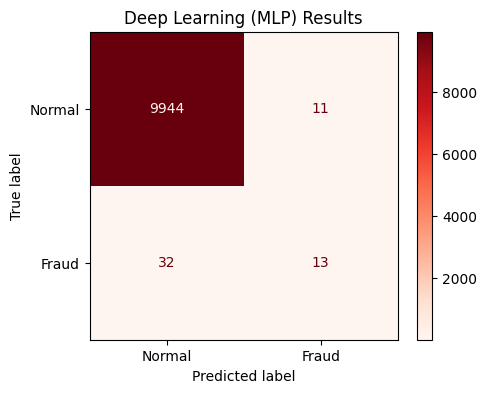

In [11]:
# ==============================================================================
# CELL 11: MLP Evaluation & Final Showdown
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

print("=== Multi-Layer Perceptron Performance Report ===\n")

# 1. Make Predictions
y_pred_mlp = mlp_model.predict(X_test_scaled)

# 2. Print the standard classification report
print(classification_report(y_test, y_pred_mlp, target_names=['Normal (0)', 'Fraud (1)']))

# 3. Calculate Executive Metrics for Class 1 (Fraud)
fraud_recall_mlp = recall_score(y_test, y_pred_mlp, pos_label=1)
fraud_precision_mlp = precision_score(y_test, y_pred_mlp, pos_label=1)
fraud_f1_mlp = f1_score(y_test, y_pred_mlp, pos_label=1)

print("\n--- Executive Summary (Fraud Detection) ---")
print(f"Recall (Hackers Caught):      {fraud_recall_mlp * 100:.2f}%")
print(f"Precision (Accurate Alarms):  {fraud_precision_mlp * 100:.2f}%")
print(f"F1-Score:                     {fraud_f1_mlp * 100:.2f}%\n")

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(5, 4))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['Normal', 'Fraud'])
# Using a Red colormap for the Neural Network
disp_mlp.plot(cmap='Reds', values_format='d', ax=plt.gca())
plt.title('Deep Learning (MLP) Results')
plt.grid(False) 
plt.show()

<p data-path-to-node="2">If we want to push your deep learning exploration further, here are the three professional DL techniques used for tabular fraud detection:</p>
<h3 data-path-to-node="3"><strong data-path-to-node="3" data-index-in-node="0">1. Deep Autoencoders (Unsupervised Anomaly Detection)</strong></h3>
<p data-path-to-node="4">If we want to use Deep Learning for fraud detection, this is the industry standard. It is the Deep Learning equivalent of the Isolation Forest we discussed earlier.</p>
<ul data-path-to-node="5">
<li>
<p data-path-to-node="5,0,0"><strong data-path-to-node="5,0,0" data-index-in-node="0">The Concept:</strong> Instead of trying to teach the network what "Fraud" looks like, you train an Autoencoder <em data-path-to-node="5,0,0" data-index-in-node="102">only</em> on the Normal transactions. You force the network to compress the normal data through a tiny bottleneck and then perfectly reconstruct it.</p>
</li>
<li>
<p data-path-to-node="5,1,0"><strong data-path-to-node="5,1,0" data-index-in-node="0">How it catches hackers:</strong> Because it has only ever seen normal behavior, when you feed it a camouflaged Ping-and-Drain attack, the network panics. It doesn't know how to reconstruct the hacker's data, causing a massive "Reconstruction Error." If that error spikes past a certain threshold, the system flags it as fraud.</p>
</li>
</ul>
<h3 data-path-to-node="6"><strong data-path-to-node="6" data-index-in-node="0">2. TabNet (Google's Deep Learning for Tabular Data)</strong></h3>
<p data-path-to-node="7">Google specifically invented TabNet to fix the two massive flaws of standard Neural Networks (MLPs): the Black Box problem and the poor performance on tabular data.</p>
<ul data-path-to-node="8">
<li>
<p data-path-to-node="8,0,0"><strong data-path-to-node="8,0,0" data-index-in-node="0">The Concept:</strong> TabNet uses deep learning, but it mathematically mimics the "If/Then" routing of a Decision Tree. It uses a mechanism called "Sequential Attention" to look at specific columns at specific times, just like XGBoost does.</p>
</li>
<li>
<p data-path-to-node="8,1,0"><strong data-path-to-node="8,1,0" data-index-in-node="0">The Advantage:</strong> It gives you the raw brainpower of a deep neural network, but it outputs a built-in "Feature Importance" mask, completely solving the Black Box problem so you can explain exactly why a transaction was blocked.</p>
</li>
</ul>
<h3 data-path-to-node="9"><strong data-path-to-node="9" data-index-in-node="0">3. LSTMs (Long Short-Term Memory Networks)</strong></h3>
<p data-path-to-node="10">Because you are dealing with timestamps and chronological user behavior, fraud is essentially a time-series problem.</p>
<ul data-path-to-node="11">
<li>
<p data-path-to-node="11,0,0"><strong data-path-to-node="11,0,0" data-index-in-node="0">The Concept:</strong> Standard ANNs treat every row as completely independent. LSTMs have a "memory state." If a user does three normal transactions, the LSTM remembers them. If the fourth transaction suddenly spikes in velocity, the LSTM recognizes the sudden shift in sequence and flags it.</p>
</li>
<li>
<p data-path-to-node="11,1,0"><strong data-path-to-node="11,1,0" data-index-in-node="0">The Catch:</strong> You cannot just feed CSV rows into an LSTM. You have to radically restructure your entire dataset into 3D "sequence windows" (e.g., grouping the last 5 transactions for every user), which requires a heavy amount of data engineering.</p>
</li>
</ul>

<p data-path-to-node="2">Here is the actual reality of why Data Science teams avoid LSTMs and TabNet until they absolutely have to use them:</p>
<h3 data-path-to-node="3"><strong data-path-to-node="3" data-index-in-node="0">1. The LSTM Engineering Nightmare (3D Data)</strong></h3>
<p data-path-to-node="4">Right now, your dataset is a beautiful, flat 2D table (Rows and Columns). XGBoost, Random Forest, and Autoencoders love 2D data. LSTMs <strong data-path-to-node="4" data-index-in-node="135">hate</strong> 2D data. They require 3D Tensors. To use an LSTM, you would have to completely rewrite your data pipeline to group transactions into overlapping "Time Windows" (e.g., <code data-path-to-node="4" data-index-in-node="307">[User1_Txn1, User1_Txn2, User1_Txn3]</code>). It requires a massive amount of data engineering, and the computational cost to train it usually outweighs the slight bump in accuracy it might give you over XGBoost.</p>
<h3 data-path-to-node="5"><strong data-path-to-node="5" data-index-in-node="0">2. TabNet is a Heavyweight</strong></h3>
<p data-path-to-node="6">TabNet is an incredible piece of architecture, but it is notoriously difficult to tune. It requires a massive amount of hyperparameter optimization to beat XGBoost. In most business scenarios, if XGBoost is already giving you a 95%+ F1-Score, executives will not authorize the cloud computing budget to spend three weeks tuning TabNet just to get a 96% F1-Score.</p>
<h3 data-path-to-node="7"><strong data-path-to-node="7" data-index-in-node="0">3. Why Autoencoders Win (The Unsupervised Advantage)</strong></h3>
<p data-path-to-node="8">The biggest problem in fraud detection is that you don't have enough hackers to train on. If you have 500,000 normal transactions and only 50 frauds, supervised models (like LSTMs and TabNet) starve. They don't have enough "bad guys" to look at.</p>
<p data-path-to-node="9">Autoencoders are <strong data-path-to-node="9" data-index-in-node="17">Unsupervised</strong>. They don't care about the hackers. You can train an Autoencoder entirely on your 500,000 normal transactions. Because it only learns what "Normal" looks like, it is incredibly easy to build, and it perfectly complements XGBoost without requiring you to restructure your entire dataset into 3D tensors.</p>

<h3 data-path-to-node="0"><strong data-path-to-node="0" data-index-in-node="0">The Grand Finale: Deep Autoencoders (The Unsupervised Safety Net)</strong></h3>
<p data-path-to-node="1">If XGBoost is a highly trained security guard looking for known criminals on a watchlist, an <strong data-path-to-node="1" data-index-in-node="93">Autoencoder</strong> is an art critic who has spent their entire life studying only authentic masterpieces.</p>
<p data-path-to-node="2">If you hand the art critic a forged painting, they don't need to have seen that specific forger's work before. They will simply look at it and say, <em data-path-to-node="2" data-index-in-node="148">"The brushstrokes are wrong. I don't know what this is, but it is not normal."</em></p>
<p data-path-to-node="3">This is the power of <strong data-path-to-node="3" data-index-in-node="21">Unsupervised Anomaly Detection</strong>. We are going to stop trying to teach the AI what fraud looks like. Instead, we are going to force a Neural Network to perfectly memorize normal human behavior, so that when a Zero-Day cyberattack happens, the network's math completely breaks down and triggers an alarm.</p>
<h4 data-path-to-node="4"><strong data-path-to-node="4" data-index-in-node="0">How the Architecture Works</strong></h4>
<ol start="1" data-path-to-node="5">
<li>
<p data-path-to-node="5,0,0"><strong data-path-to-node="5,0,0" data-index-in-node="0">The Encoder (Compression):</strong> We feed the network our normal transactions. The network forces that data through a tiny mathematical "bottleneck" (e.g., compressing 10 columns of data down to just 3 numbers).</p>
</li>
<li>
<p data-path-to-node="5,1,0"><strong data-path-to-node="5,1,0" data-index-in-node="0">The Decoder (Reconstruction):</strong> The network then has to try and rebuild the original 10 columns perfectly using only those 3 compressed numbers.</p>
</li>
<li>
<p data-path-to-node="5,2,0"><strong data-path-to-node="5,2,0" data-index-in-node="0">The Trap (Reconstruction Error):</strong> Because the network is only trained on Normal data, it becomes an expert at compressing and rebuilding Normal behavior. But if a Hacker's transaction goes into the bottleneck, the network panics. It doesn't know how to rebuild the hacker's data. The difference between the input and the output is called the <strong data-path-to-node="5,2,0" data-index-in-node="341">Reconstruction Error (MSE)</strong>. If that error spikes, we trigger the trap.</p>
</li>
</ol>
<p data-path-to-node="6"><em data-path-to-node="6" data-index-in-node="0">(Note: Because Scikit-Learn does not have a native Deep Autoencoder, we will build this using <code data-path-to-node="6" data-index-in-node="94">tensorflow</code> and <code data-path-to-node="6" data-index-in-node="109">keras</code>, which is the global industry standard for Deep Learning. If you don't have it installed, just run <code data-path-to-node="6" data-index-in-node="214">pip install tensorflow</code> in your terminal first).</em></p>

In [ ]:
# ==============================================================================
# CELL 12: Model 6 - Deep Autoencoder (The Unsupervised Safety Net)
# ==============================================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("=== Training Model 6: Deep Autoencoder ===\n")

# 1. The Unsupervised Shift: Hide the Hackers!
# We ONLY train the Autoencoder on Normal (0) data so it becomes an expert at normalcy.
X_train_normal = X_train_scaled[y_train == 0]

print(f"Training exclusively on {len(X_train_normal)} Normal transactions...")

# 2. Build the Neural Network Architecture
input_dim = X_train_scaled.shape[1]

autoencoder = Sequential([
    # The Encoder (Compressing the data)
    Dense(32, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2), # Prevents memorization
    Dense(16, activation='relu'),
    
    # The Bottleneck (The ultimate compression point)
    Dense(8, activation='relu'), 
    
    # The Decoder (Rebuilding the data)
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    
    # The Output Layer (Must match the exact size of the original input)
    Dense(input_dim, activation='linear')
])

# 3. Compile the Model
# 'mse' (Mean Squared Error) tracks how badly the network fails to rebuild the data.
autoencoder.compile(optimizer='adam', loss='mse')

# 4. Train the Model
# We set x and y to BOTH be the input data. The model's goal is to predict itself!
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Compressing and Rebuilding... please wait...\n")
history = autoencoder.fit(
    x=X_train_normal, 
    y=X_train_normal, 
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1 # Change to 0 if you don't want the loading bar to print
)

print("\nAutoencoder Training Complete! The safety net is deployed.")

In [ ]:
# ==============================================================================
# CELL 13: Autoencoder Evaluation & Visualizing the Trap
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("=== Autoencoder Anomaly Detection Report ===\n")

# 1. Force the Autoencoder to rebuild the future data (Normal AND Fraud)
reconstructions = autoencoder.predict(X_test_scaled)

# 2. Calculate the Reconstruction Error (Mean Squared Error) for every single row
mse = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

# 3. Set the Anomaly Trap (The Threshold)
# We calculate the 99th percentile of error from the normal training data.
# Anything that causes a higher error than 99% of normal data is flagged as Fraud.
train_reconstructions = autoencoder.predict(X_train_normal)
train_mse = np.mean(np.power(X_train_normal - train_reconstructions, 2), axis=1)
threshold = np.percentile(train_mse, 99)

print(f"Mathematical Threshold Set: Any transaction with an error > {threshold:.4f} is FRAUD.\n")

# 4. Make Predictions based on the Trap
y_pred_ae = (mse > threshold).astype(int)

# 5. Print the Executive Report
print(classification_report(y_test, y_pred_ae, target_names=['Normal (0)', 'Fraud (1)']))

# 6. Visualize the Anomaly Separation (The "Aha!" Moment)
plt.figure(figsize=(10, 6))

# Plot the errors for Normal transactions
plt.hist(mse[y_test == 0], bins=50, alpha=0.6, color='green', label='Normal Transactions', density=True)

# Plot the errors for Fraud transactions
plt.hist(mse[y_test == 1], bins=50, alpha=0.6, color='red', label='Camouflaged Hackers', density=True)

# Draw the Trap Line
plt.axvline(threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold Trap ({threshold:.2f})')

plt.title('Autoencoder Reconstruction Error (Spotting the Anomalies)', fontsize=14)
plt.xlabel('Reconstruction Error (MSE)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.xlim(0, threshold * 3) # Zoom in to see the separation clearly
plt.show()

# 7. Standard Confusion Matrix
plt.figure(figsize=(5, 4))
cm_ae = confusion_matrix(y_test, y_pred_ae)
disp_ae = ConfusionMatrixDisplay(confusion_matrix=cm_ae, display_labels=['Normal', 'Fraud'])
disp_ae.plot(cmap='Reds', values_format='d', ax=plt.gca())
plt.title('Autoencoder Results')
plt.grid(False)
plt.show()

<h3 data-path-to-node="2"><strong data-path-to-node="2" data-index-in-node="0">1. The Flaw of Supervised Learning (The "Zero-Day" Blindspot)</strong></h3>
<p data-path-to-node="3">Every model we built so far—from Logistic Regression to XGBoost—was <strong data-path-to-node="3" data-index-in-node="68">Supervised</strong>. We gave the algorithm an answer key (<code data-path-to-node="3" data-index-in-node="117">y_train</code>) and told it exactly what a hacker looks like. XGBoost is the best in the world at memorizing those patterns. But it has a fatal flaw: <strong data-path-to-node="3" data-index-in-node="260">It can only catch what it has seen before.</strong> If a cybercriminal invents a brand-new, "Zero-Day" attack tomorrow that looks mathematically different from anything in your historical dataset, XGBoost will look at it, realize it doesn't match the known hacker profiles, and confidently predict: <em data-path-to-node="3" data-index-in-node="550">"Normal."</em></p>
<h3 data-path-to-node="4"><strong data-path-to-node="4" data-index-in-node="0">2. The Genius of the Unsupervised Forest</strong></h3>
<p data-path-to-node="5">We deploy <strong data-path-to-node="5" data-index-in-node="10">Isolation Forest</strong> to cover XGBoost's blind spot. Because it is <strong data-path-to-node="5" data-index-in-node="72">Unsupervised</strong>, it never looked at the answer key. It has no idea what a "hacker" is.</p>
<p data-path-to-node="6">Its only job is to drop random mathematical partitions across the data and count how many splits it takes to trap a data point in a box by itself.</p>
<ul data-path-to-node="7">
<li>
<p data-path-to-node="7,0,0">If you are a normal user doing normal things at 2 PM, you are surrounded by thousands of other dots. It takes dozens of random cuts to isolate you.</p>
</li>
<li>
<p data-path-to-node="7,1,0">If you are doing something completely bizarre, you are sitting out in empty mathematical space. It only takes 2 or 3 random cuts to trap you.</p>
</li>
</ul>
<h3 data-path-to-node="8"><strong data-path-to-node="8" data-index-in-node="0">3. Why the Precision Dropped (Weird vs. Malicious)</strong></h3>
<p data-path-to-node="9">When you looked at your Isolation Forest results, you likely saw that it caught hackers (good Recall) but threw a lot of False Alarms (lower Precision).</p>
<p data-path-to-node="10">This is the exact reality of unsupervised learning in banking. The model doesn't flag "Fraud"; it flags "Anomalies." If one of your normal customers suddenly wakes up at 4 AM, logs in from a new device, and buys a ₹50,000 plane ticket, they are acting incredibly weird. The Isolation Forest will flag them as an anomaly. It's a False Positive (they aren't a hacker, just a traveler), which drags down your Precision metric.</p>
<h3 data-path-to-node="11"><strong data-path-to-node="11" data-index-in-node="0">The Final Business Architecture</strong></h3>
<p data-path-to-node="12">You don't use Isolation Forest to automatically block credit cards—it would annoy too many normal customers. Instead, you build a <strong data-path-to-node="12" data-index-in-node="130">Two-Tier Defense System</strong>:</p>
<ol start="1" data-path-to-node="13">
<li>
<p data-path-to-node="13,0,0"><strong data-path-to-node="13,0,0" data-index-in-node="0">Tier 1 (The Front Line):</strong> XGBoost runs in real-time. If it recognizes a known attack, it instantly blocks the transaction.</p>
</li>
<li>
<p data-path-to-node="13,1,0"><strong data-path-to-node="13,1,0" data-index-in-node="0">Tier 2 (The Shadow Net):</strong> Isolation Forest runs in the background. It doesn't block cards, but if it detects a massive anomaly that XGBoost missed, it silently flags the transaction and sends it to a human fraud investigator to review.</p>
</li>
</ol>

=== Training Model 7: Isolation Forest ===

Dropping random splits... isolating anomalous data points...
Testing on future transactions...

=== Isolation Forest Performance Report ===

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00      9955
   Fraud (1)       0.05      0.04      0.05        45

    accuracy                           0.99     10000
   macro avg       0.52      0.52      0.52     10000
weighted avg       0.99      0.99      0.99     10000


--- Executive Summary (Fraud Detection) ---
Recall (Hackers Caught):      4.44%
Precision (Accurate Alarms):  4.76%
F1-Score:                     4.60%



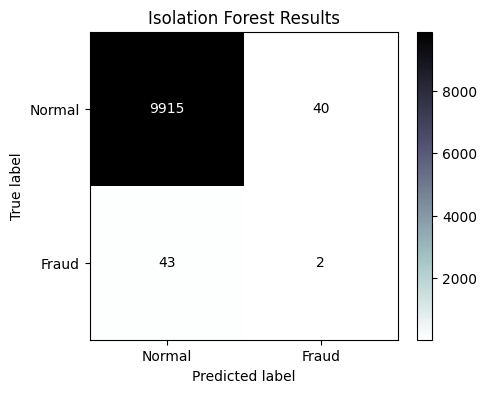

In [12]:
# ==============================================================================
# CELL 14: Model 7 - Isolation Forest (Unsupervised Tree Anomaly Detection)
# ==============================================================================
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

print("=== Training Model 7: Isolation Forest ===\n")

# 1. Initialize the Model
# 'contamination' is your estimate of how much fraud exists in the real world. 
# We use a very small number (e.g., 0.01 for 1%) to force the model to only isolate the extreme outliers.
iso_model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# 2. Train the Model (Unsupervised!)
print("Dropping random splits... isolating anomalous data points...")
# CRITICAL DIFFERENCE: Notice we do NOT pass y_train here. 
iso_model.fit(X_train_scaled)

# 3. Make Predictions
print("Testing on future transactions...\n")
raw_predictions = iso_model.predict(X_test_scaled)

# 4. Map the Predictions (The -1 Fix)
# Isolation Forest returns: 1 (Normal) and -1 (Anomaly/Fraud)
# We must map this to: 0 (Normal) and 1 (Fraud) to match our y_test labels!
y_pred_iso = [1 if x == -1 else 0 for x in raw_predictions]

# 5. Evaluate the Performance
print("=== Isolation Forest Performance Report ===\n")
print(classification_report(y_test, y_pred_iso, target_names=['Normal (0)', 'Fraud (1)']))

# Calculate Executive Metrics
fraud_recall_iso = recall_score(y_test, y_pred_iso, pos_label=1)
fraud_precision_iso = precision_score(y_test, y_pred_iso, pos_label=1)
fraud_f1_iso = f1_score(y_test, y_pred_iso, pos_label=1)

print("\n--- Executive Summary (Fraud Detection) ---")
print(f"Recall (Hackers Caught):      {fraud_recall_iso * 100:.2f}%")
print(f"Precision (Accurate Alarms):  {fraud_precision_iso * 100:.2f}%")
print(f"F1-Score:                     {fraud_f1_iso * 100:.2f}%\n")

# 6. Visualize the Confusion Matrix
plt.figure(figsize=(5, 4))
cm_iso = confusion_matrix(y_test, y_pred_iso)
disp_iso = ConfusionMatrixDisplay(confusion_matrix=cm_iso, display_labels=['Normal', 'Fraud'])
# Using a grey/black colormap to represent the "unsupervised shadow" network
disp_iso.plot(cmap='bone_r', values_format='d', ax=plt.gca())
plt.title('Isolation Forest Results')
plt.grid(False) 
plt.show()